In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

mengimport library yang dibutuhkan seperti:

* pandas, untuk manipulasi data
* numpy, untuk kalkulasi matematika
* matplotlib.pyplot, untuk visualisasi
* train_test_split, untuk membagi data
* LinearRegression, untuk membangun model linear regresi
* metrics, untuk mengukur tingkat akurasi



In [44]:
data = {
    'sks': [20, 24, 18, 22, 24, 20, 19, 21, 23, 18],
    'jamKegiatanEkstra': [5, 10, 2, 8, 12, 4, 3, 6, 9, 1],
    'persentaseKehadiran': [95, 80, 100, 90, 75, 98, 92, 88, 85, 100],
    'ipSemester': [3.5, 3.2, 3.8, 3.4, 3.0, 3.6, 3.7, 3.5, 3.3, 3.9]
}

df = pd.DataFrame(data)
print(df)

   sks  jamKegiatanEkstra  persentaseKehadiran  ipSemester
0   20                  5                   95         3.5
1   24                 10                   80         3.2
2   18                  2                  100         3.8
3   22                  8                   90         3.4
4   24                 12                   75         3.0
5   20                  4                   98         3.6
6   19                  3                   92         3.7
7   21                  6                   88         3.5
8   23                  9                   85         3.3
9   18                  1                  100         3.9


Mendefinisikan nilai dari data yang akan digunakan dan mengubahkan menjadi format yang terstruktur yaitu Pandas DataFrame (df).

In [45]:
X = df[['sks', 'jamKegiatanEkstra', 'persentaseKehadiran']]
y = df['ipSemester']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Memisahkan data menjadi dua bagian: variabel X (independen) yang menampung fitur-fitur pendukung seperti SKS, Jam Kegiatan, dan Kehadiran, serta variabel y (dependen) yang menampung target yang ingin diprediksi, yaitu IP Semester.

Lalu membagi data training dan data testing dimana 80% data digunakan untuk training model dan 20% sisanya disisihkan untuk testing.

In [47]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [48]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)

Intercept (a): 3.510507757404797
Koefisien (b1, b2, b3): [ 0.0212976  -0.08787024  0.0006347 ]


Proses pembelajaran dimulai, dimana sistem mencari hubungan antar variable pada data training, lalu menghitung persamaan garis linear terbaik.


In [49]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Nilai Asli:", y_test.values)

Prediksi: [3.26346968 3.19372355]
Nilai Asli: [3.3 3.2]


`model.predict(X_test)`: memasukkan data hari pengujian (testing) yang disembunyikan ke dalam model, lalu menyuruh model menebak berapa pengeluarannya.

In [50]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.02140338504936601
MSE: 0.0006869291857062644
RMSE: 0.026209333942438604


Metrik Error (MAE, MSE, RMSE): Bagian ini menghitung seberapa jauh tebakan model (y_pred) menyimpang dari data asli yang disembunyikan (y_test). Semakin kecil angkanya, semakin akurat modelnya.

In [51]:
data_baru = [[22, 7, 95]]
prediksi = model.predict(data_baru)

print("Prediksi performa mahasiswa:", round(prediksi[0], 2))

Prediksi performa mahasiswa: 3.42


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


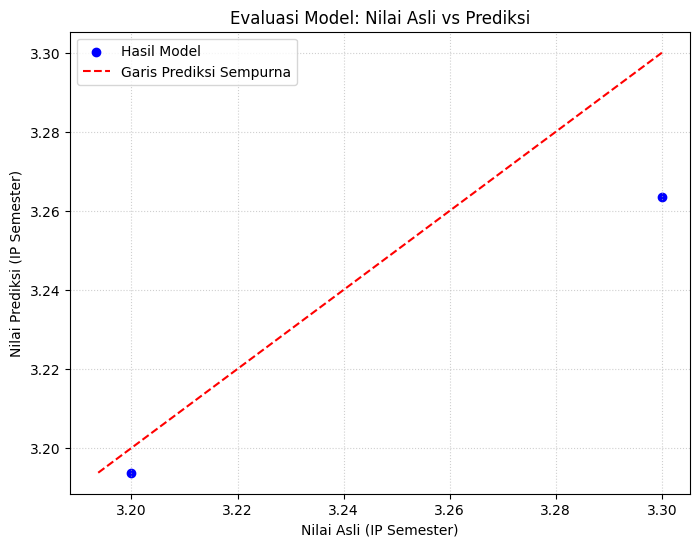

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, color='blue', label='Hasil Model')

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Garis Prediksi Sempurna')

plt.xlabel('Nilai Asli (IP Semester)')
plt.ylabel('Nilai Prediksi (IP Semester)')
plt.title('Evaluasi Model: Nilai Asli vs Prediksi')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Membuat grafik evaluasi untuk membandingkan Nilai Asli vs Nilai Prediksi. Titik biru mewakili hasil tebakan model, sedangkan garis merah putus-putus adalah garis linear sempurna. Semakin dekat titik biru ke garis merah, maka model semakin akurat dalam melakukan prediksi.